In [ ]:
# What is pandas?
# Pandas is a Python library (a toolkit someone else built) for working with tabular data — rows and columns, like Excel. It lets you load a CSV, filter it, group it, and calculate things, all with code instead of clicking around a spreadsheet.

In [ ]:
import pandas as pd
df = pd.read_csv('Fleet Data.csv')
df.head()

,Parent Airline,Airline,Aircraft Type,Current,Future,Historic,Total,Orders,Unit Cost,Total Cost (Current),Average Age
0,Aegean Airlines,Aegean Airlines,Airbus A319,1.0,NaN,3.0,4.0,NaN,$90,$90,11.6
1,Aegean Airlines,Olympic Air,Airbus A319,NaN,NaN,8.0,8.0,NaN,$90,$0,NaN
2,Aegean Airlines,Aegean Airlines,Airbus A320,38.0,NaN,3.0,41.0,NaN,$98,"$3,724",7.5
3,Aegean Airlines,Olympic Air,Airbus A320,NaN,NaN,9.0,9.0,NaN,$98,$0,NaN
4,Aegean Airlines,Aegean Airlines,Airbus A321,8.0,NaN,NaN,8.0,NaN,$115,$919,10.3


In [ ]:
# Concept: .shape and .info()

#  .shape tells you how many rows and columns you have (like checking how big your Excel sheet is)
#  n.info() tells you each column's name, how many non-empty values it has, and its data type (text, number, etc.) — this is how you spot missing data and wrong data types fast

In [2]:
print(df.shape)
df.info()

(1583, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1583 entries, 0 to 1582
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Parent Airline        1583 non-null   object 
 1   Airline               1583 non-null   object 
 2   Aircraft Type         1583 non-null   object 
 3   Current               859 non-null    float64
 4   Future                188 non-null    float64
 5   Historic              1113 non-null   float64
 6   Total                 1484 non-null   float64
 7   Orders                348 non-null    float64
 8   Unit Cost             1548 non-null   object 
 9   Total Cost (Current)  1556 non-null   object 
 10  Average Age           820 non-null    float64
dtypes: float64(6), object(5)
memory usage: 136.2+ KB


In [ ]:
# 1583 rows, 11 columns — that's full dataset
# current = key coloumn. has only 859 non-null out of 1583 → almost half is missing (NaN). Makes sense: some rows are "Future" or "Historic" only entries, not current fleet.
# Unit Cost and Total Cost (Current) are object type, not numbers.

In [ ]:
# Concept: .dropna()
# Since our analysis is about the current fleet, rows where Current is NaN (missing) are useless to us — they're either future orders or retired planes with no "in service" count. .dropna() removes rows with missing values in a specified column.


In [3]:
df_clean = df.dropna(subset=['Current'])
print(df_clean.shape)

(859, 11)


In [ ]:
# Concept: .value_counts()
# This counts how many times each unique value appears in a column — like a quick frequency count. But here we don't just want to count rows, we want to sum the actual fleet numbers (Current) per aircraft type, since one row = one airline's count of that plane, not one plane.

# Concept: .groupby()
# Groups your data by a column (like a pivot table's "Rows" field), so you can then aggregate (sum, average, etc.) another column per group.

In [5]:
fleet_by_type = df_clean.groupby('Aircraft Type')['Current'].sum().sort_values(ascending=False)
print(fleet_by_type.head(10))

Aircraft Type
Boeing 737         5328.0
Airbus A320        3299.0
Boeing 777         1305.0
Airbus A321        1231.0
Airbus A319        1188.0
Airbus A330        1083.0
Boeing 767          610.0
Embraer ERJ-170     576.0
Boeing 757          556.0
Embraer ERJ-190     551.0
Name: Current, dtype: float64


In [ ]:
# Concept: .str.contains()
# This checks whether a text column contains a certain word/substring — like Excel's IF(ISNUMBER(SEARCH(...))). We'll use it to tag each row as Boeing, Airbus, or Other based on the Aircraft Type text.

In [6]:
def get_manufacturer(aircraft_type):
    if 'Boeing' in aircraft_type:
        return 'Boeing'
    elif 'Airbus' in aircraft_type:
        return 'Airbus'
    else:
        return 'Other'

df_clean['Manufacturer'] = df_clean['Aircraft Type'].apply(get_manufacturer)

manufacturer_totals = df_clean.groupby('Manufacturer')['Current'].sum().sort_values(ascending=False)
print(manufacturer_totals)

Manufacturer
Boeing    8773.0
Airbus    7440.0
Other     4432.0
Name: Current, dtype: float64


/tmp/ipykernel_3405/2493559188.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Manufacturer'] = df_clean['Aircraft Type'].apply(get_manufacturer)


In [ ]:
# Concept: SettingWithCopyWarning
# When you did df_clean = df.dropna(...) earlier, pandas wasn't 100% sure if df_clean is a totally separate DataFrame or just a "view" into the original df. So when you added a new column to df_clean, it warns you just in case. Your result was correct here, but the fix is good practice going forward.

# The fix: add .copy() when you first create df_clean, back in Step 3. Go back to that cell and change it to:

In [7]:
df_clean = df.dropna(subset=['Current']).copy()

In [8]:
def get_manufacturer(aircraft_type):
    if 'Boeing' in aircraft_type:
        return 'Boeing'
    elif 'Airbus' in aircraft_type:
        return 'Airbus'
    else:
        return 'Other'

df_clean['Manufacturer'] = df_clean['Aircraft Type'].apply(get_manufacturer)

manufacturer_totals = df_clean.groupby('Manufacturer')['Current'].sum().sort_values(ascending=False)
print(manufacturer_totals)

Manufacturer
Boeing    8773.0
Airbus    7440.0
Other     4432.0
Name: Current, dtype: float64


In [10]:
fleet_by_airline = df_clean.groupby('Airline')['Current'].sum().sort_values(ascending=False)
print(fleet_by_type.head(10))

Airline
American Airlines          928.0
Delta Airlines             855.0
United Airlines            730.0
Southwest Airlines         718.0
China Southern Airlines    522.0
China Eastern Airlines     451.0
FedEx Express              408.0
Air China                  375.0
RyanAir                    366.0
American Eagle             297.0
Name: Current, dtype: float64


In [ ]:
# Concept: matplotlib
# This is Python's basic charting library — think of it as the "Insert Chart" button in Excel, but code-based. .plot(kind='bar') turns a pandas result straight into a bar chart.

In [16]:
plt.rcParams['font.family'] = 'serif'

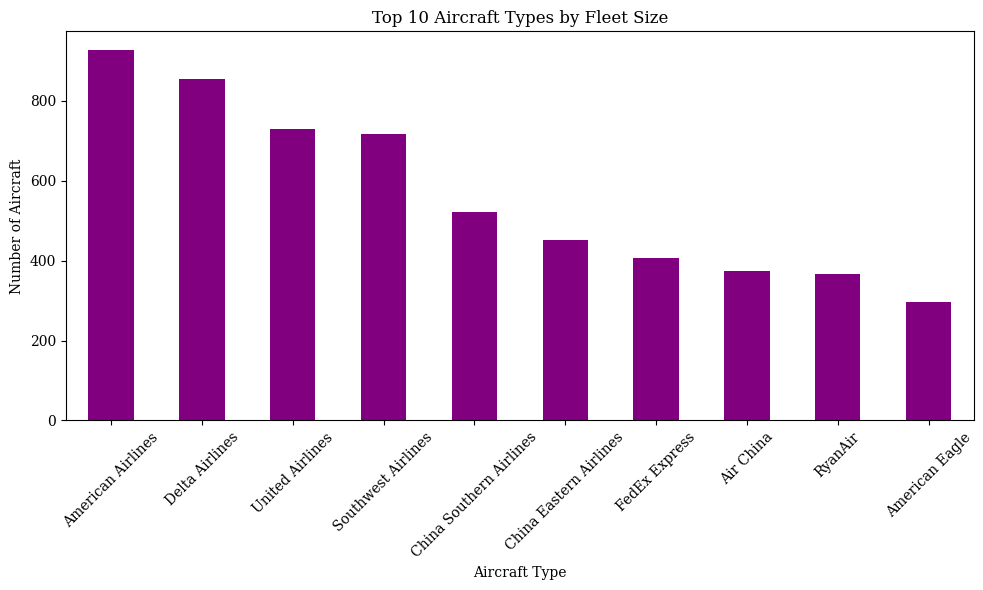

In [17]:
import matplotlib.pyplot as plt

fleet_by_type.head(10).plot(kind='bar', figsize=(10,6), color='purple')
plt.title('Top 10 Aircraft Types by Fleet Size')
plt.xlabel('Aircraft Type')
plt.ylabel('Number of Aircraft')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Lesson for your notes: plt.rcParams[...] is a global setting — it affects every chart in the notebook
# from that point on, not just one. Good to know since it can cause confusing bugs later
# (a chart "mysteriously" changing style with no visible reason in that cell).